# Testing 21cmFast

## Initial testing

### Importing modules

In [1]:
import py21cmfast as p21c
from tempfile import mkdtemp
from pathlib import Path
from matplotlib import pyplot as plt

print(f' Using 21cmFAST version {p21c.__version__}')

 Using 21cmFAST version 4.2


### Defining Simulation inputs

The list of template configurations we want to load as defaults include:
    The configuration from Park et al. 2019 (`Park19`)
    A box with preset size and resolution

In [2]:
"""Differences between Park19 Model and this one:

HII_DIM=512
LOWRES_CELL_SIZE_MPC=2
PERTURB_ON_HIGH_RES = True

From Meiksin 2021 and Reis et al. 2021:
- USE_CMB_HEATING = True
- USE_LYA_HEATING = True

From Qin et al. 2024 (Table 1):

- F_STAR10 = -1.42
- ALPHA_STAR = 0.51
- F_ESC10 = -1.08
- ALPHA_ESC = -0.46
- t_STAR = 0.34
- M_TURN = 8.46

This assumes a constant f_esc. Pursuing a non-constant f_esc will be optional later on.
"""

# Define inputs
scin_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"],
    random_seed = 20250303,
    HII_DIM = 512,
    LOWRES_CELL_SIZE_MPC = 2,
    N_THREADS = 8,
    USE_CMB_HEATING = True,
    USE_LYA_HEATING = True,
    F_STAR10 = -1.42,
    ALPHA_STAR = 0.51,
    F_ESC10 = -1.08,
    ALPHA_ESC = -0.46,
    t_STAR = 0.34,
    M_TURN = 8.46
)

test_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"],
    random_seed = 20250303,
    HII_DIM = 128,
    LOWRES_CELL_SIZE_MPC = 2,
    N_THREADS = 8,
    USE_CMB_HEATING = True,
    USE_LYA_HEATING = True,
    F_STAR10 = -1.42,
    ALPHA_STAR = 0.51,
    F_ESC10 = -1.08,
    ALPHA_ESC = -0.46,
    t_STAR = 0.34,
    M_TURN = 8.46
)

test_toml_file = "test-park19.toml"
scin_toml_file = "scin-park19.toml"

p21c.write_template(test_inputs, test_toml_file)
p21c.write_template(scin_inputs, scin_toml_file)

## Running the test lightcone file

In [3]:
cache = p21c.OutputCache(mkdtemp())

lcn = p21c.RectilinearLightconer.between_redshifts(
    min_redshift=5.5,
    max_redshift=12.0,
    quantities=("brightness_temp", "density"),
    resolution=test_inputs.simulation_options.cell_size
)

In [4]:
lightcone = p21c.run_lightcone(
    lightconer=lcn,
    inputs=test_inputs,
    cache=cache,
    progressbar=True
)

Output()

Output()

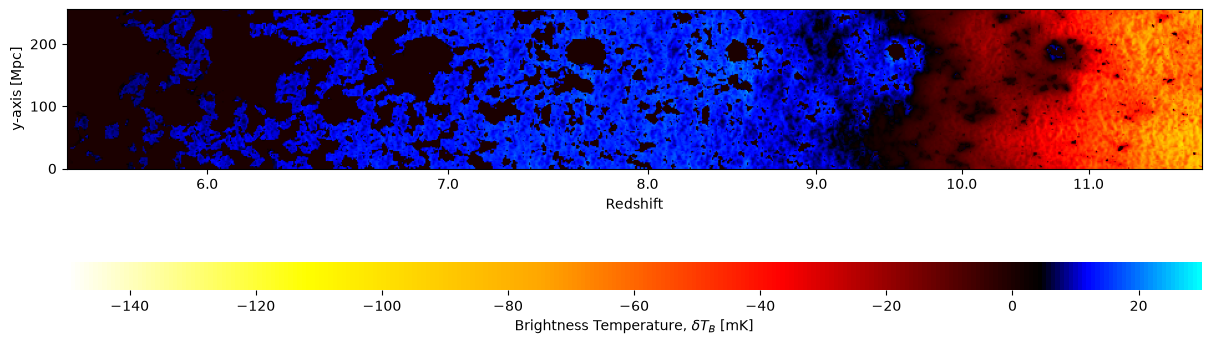

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
p21c.plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);

In [6]:
print(lightcone.lightcones)

{'brightness_temp': array([[[  0.        ,   0.        ,   0.        , ..., -88.46474   ,
         -87.80367   , -87.3743    ],
        [  0.        ,   0.        ,   0.        , ..., -87.9768    ,
         -65.83841   , -49.09737   ],
        [  0.        ,   0.        ,   0.        , ..., -78.67993   ,
         -64.051186  , -82.22925   ],
        ...,
        [  0.        ,   0.        ,   0.        , ..., -60.522064  ,
         -70.36176   , -87.7199    ],
        [  0.        ,   0.        ,   0.        , ..., -64.88809   ,
         -68.26094   , -84.68118   ],
        [  0.        ,   0.        ,   0.        , ..., -82.4592    ,
         -83.262856  , -87.53486   ]],

       [[  0.        ,   0.        ,   0.        , ..., -92.10662   ,
         -86.619545  , -73.80312   ],
        [  0.        ,   0.        ,   0.        , ..., -93.94291   ,
         -91.73782   , -81.44333   ],
        [  0.        ,   0.        ,   0.        , ..., -94.20146   ,
         -87.51222   , -80.3264